# Global Water Consumption Analysis and Prediction Using Machine Learning

## 1.PROBLEM STATEMENT

#### This project aims to analyze global water consumption data from 2000 to 2025, identify key factors affecting water usage, The project develops and evaluates multiple machine learning classification models to accurately predict the Water Scarcity Level based on water usage patterns, rainfall impact, groundwater depletion.While providing insights to support sustainable water resource management.

## 2.Importing Libraries

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## 3.Loading the Dataset

In [33]:
df = pd.read_csv(r'E:\PG 32 ML\Cap_stone_water\global_water_consumption_2000_2025.csv')
df

,Country,Year,Total Water Consumption (Billion m3),Per Capita Water Use (L/Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (mm),Groundwater Depletion Rate (%),Water Scarcity Level
0,China,2000,586.04,146.6,63.8,23.1,13.1,633.8,3.99,High
1,China,2001,590.09,161.4,63.7,23.2,13.2,854.9,4.16,High
2,China,2002,600.00,150.2,63.6,23.2,13.2,1280.2,4.24,Moderate
3,China,2003,610.45,162.5,63.5,23.3,13.3,900.1,4.40,High
4,China,2004,617.08,148.7,63.4,23.3,13.3,641.2,4.57,High
...,...,...,...,...,...,...,...,...,...,...
3895,Bahrain,2021,36.71,276.2,64.9,22.7,12.4,531.2,2.86,Low
3896,Bahrain,2022,37.11,276.1,64.8,22.8,12.5,1521.8,2.99,Low
3897,Bahrain,2023,37.29,284.5,64.7,22.8,12.5,623.9,3.08,Low
3898,Bahrain,2024,37.85,268.5,64.6,22.9,12.6,773.4,3.19,Low


## 4.Dataset Overview

In [34]:
df.head()

,Country,Year,Total Water Consumption (Billion m3),Per Capita Water Use (L/Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (mm),Groundwater Depletion Rate (%),Water Scarcity Level
0,China,2000,586.04,146.6,63.8,23.1,13.1,633.8,3.99,High
1,China,2001,590.09,161.4,63.7,23.2,13.2,854.9,4.16,High
2,China,2002,600.00,150.2,63.6,23.2,13.2,1280.2,4.24,Moderate
3,China,2003,610.45,162.5,63.5,23.3,13.3,900.1,4.40,High
4,China,2004,617.08,148.7,63.4,23.3,13.3,641.2,4.57,High


In [35]:
df.tail()

,Country,Year,Total Water Consumption (Billion m3),Per Capita Water Use (L/Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (mm),Groundwater Depletion Rate (%),Water Scarcity Level
3895,Bahrain,2021,36.71,276.2,64.9,22.7,12.4,531.2,2.86,Low
3896,Bahrain,2022,37.11,276.1,64.8,22.8,12.5,1521.8,2.99,Low
3897,Bahrain,2023,37.29,284.5,64.7,22.8,12.5,623.9,3.08,Low
3898,Bahrain,2024,37.85,268.5,64.6,22.9,12.6,773.4,3.19,Low
3899,Bahrain,2025,38.45,287.7,64.5,22.9,12.6,1068.3,3.35,Low


In [36]:
df.columns

Index(['Country', 'Year', 'Total Water Consumption (Billion m3)',
       'Per Capita Water Use (L/Day)', 'Agricultural Water Use (%)',
       'Industrial Water Use (%)', 'Household Water Use (%)',
       'Rainfall Impact (mm)', 'Groundwater Depletion Rate (%)',
       'Water Scarcity Level'],
      dtype='object')

In [37]:
df.shape

(3900, 10)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               3900 non-null   object 
 1   Year                                  3900 non-null   int64  
 2   Total Water Consumption (Billion m3)  3900 non-null   float64
 3   Per Capita Water Use (L/Day)          3900 non-null   float64
 4   Agricultural Water Use (%)            3900 non-null   float64
 5   Industrial Water Use (%)              3900 non-null   float64
 6   Household Water Use (%)               3900 non-null   float64
 7   Rainfall Impact (mm)                  3900 non-null   float64
 8   Groundwater Depletion Rate (%)        3900 non-null   float64
 9   Water Scarcity Level                  3900 non-null   object 
dtypes: float64(7), int64(1), object(2)
memory usage: 304.8+ KB


#### The Global Water Consumption dataset contains historical information on water usage from different countries between 2000 and 2025. It includes environmental, and sector-wise water consumption features such as agricultural, industrial, household water use, rainfall impact, groundwater depletion, and per capita water consumption.The objective of this dataset is to predict the Water Scarcity Level using supervised machine learning classification algorithms.

## 5.Column Description

| Column | Description |
|---|---|
| **Country** | Country where the observation was recorded |
| **Year** | Year of observation (2000-2025) |
| **Total Water Consumption (Billion m3)** | Total annual water consumed by the country |
| **Per Capita Water Use (L/Day)** | Average daily water use per person |
| **Agricultural Water Use (%)** | Share of water used for agriculture |
| **Industrial Water Use (%)** | Share of water used by industry |
| **Household Water Use (%)** | Share of water used domestically |
| **Rainfall Impact (mm)** | Annual rainfall contribution affecting water availability |
| **Groundwater Depletion Rate (%)** | Rate of groundwater depletion |
| **Water Scarcity Level** | Target variable: Low / Moderate / High / Critical |

## 6.Data Preprocessing and Data Wrangling

In [39]:
df.isnull().sum()

Country                                 0
Year                                    0
Total Water Consumption (Billion m3)    0
Per Capita Water Use (L/Day)            0
Agricultural Water Use (%)              0
Industrial Water Use (%)                0
Household Water Use (%)                 0
Rainfall Impact (mm)                    0
Groundwater Depletion Rate (%)          0
Water Scarcity Level                    0
dtype: int64

In [40]:
df['Country'].value_counts()

Country
China              26
India              26
USA                26
Indonesia          26
Pakistan           26
                   ..
North Macedonia    26
Slovenia           26
Guinea-Bissau      26
Latvia             26
Bahrain            26
Name: count, Length: 150, dtype: int64

## 7.Statistical Summary

In [41]:
df.describe()

,Year,Total Water Consumption (Billion m3),Per Capita Water Use (L/Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (mm),Groundwater Depletion Rate (%)
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,2012.500000,65.812751,232.510769,62.593333,20.209667,17.198000,998.641205,2.854062
std,7.500962,86.514606,80.096347,7.694847,4.843844,6.008282,507.662739,1.226853
min,2000.000000,10.330000,55.300000,29.700000,5.400000,0.400000,51.900000,0.150000
25%,2006.000000,27.357500,161.375000,58.300000,17.300000,12.700000,644.050000,1.960000
50%,2012.500000,50.485000,239.100000,62.100000,20.400000,17.000000,962.950000,2.820000
75%,2019.000000,75.070000,299.725000,66.100000,23.000000,21.500000,1304.300000,3.690000
max,2025.000000,766.410000,495.900000,86.600000,43.600000,30.900000,3197.700000,7.230000


1) The average total water consumption is 65.812751 indicating significant differences in water demand  
2) Rainfall Impact varies significantly, indicating diverse climatic conditions.  
3) Groundwater Depletion Rate demonstrates varying levels of groundwater extraction across different regions

### 1) Which countries are the top 5 consumers of water?

In [42]:
df.groupby('Country').agg(water_consumption_in_billion=('Total Water Consumption (Billion m3)', 'sum')
                         ).sort_values(ascending=False, by='water_consumption_in_billion').head(5) 

,water_consumption_in_billion
Country,
China,17450.01
India,15260.27
USA,13611.26
Brazil,8359.02
Russia,7664.33


Global Top Consumers: China, India, USA, Brazil and Russia

### 2) What are the places where the consumption is high yet scarcity is high?

In [43]:
df[df['Water Scarcity Level']=='High'].groupby('Country').agg(
    water_consumption_in_billion=('Total Water Consumption (Billion m3)', 'sum')
).sort_values(ascending=False, by='water_consumption_in_billion')  

,water_consumption_in_billion
Country,
China,16850.01
USA,6786.21
Israel,2198.23
Qatar,2179.69
Iran,2174.43
Namibia,1693.14
Saudi Arabia,1449.35
Kuwait,1318.40
Australia,581.49


Amongst the top consumers, only China and USA fall into the scarcity list

## EXPLORATORY DATA ANALYSIS

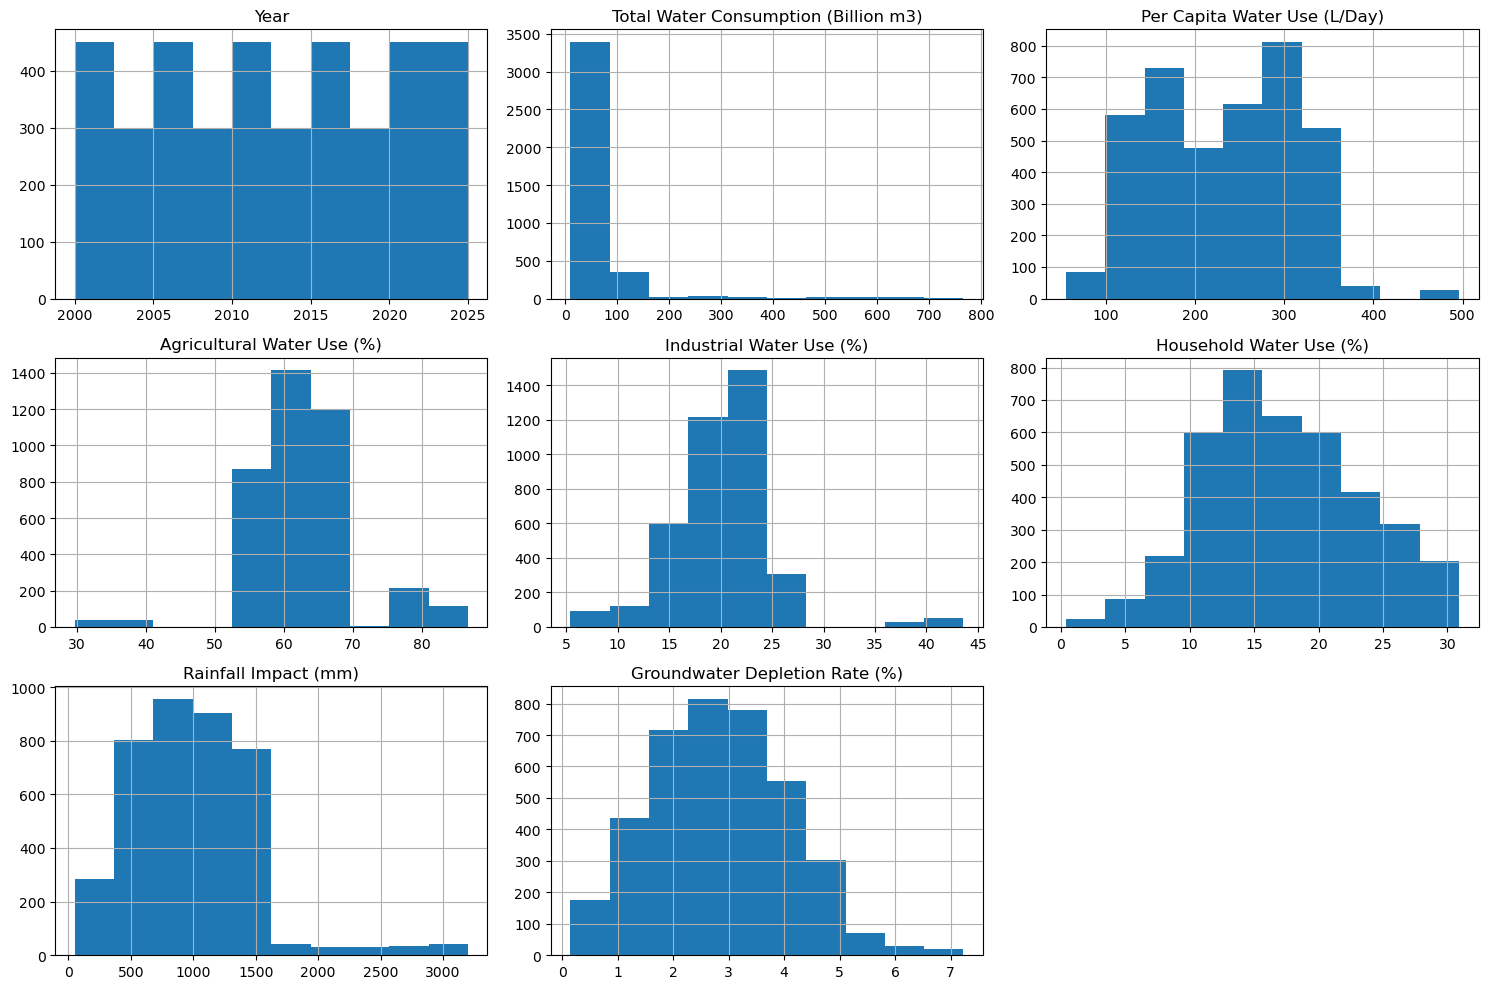

In [44]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show() 

1) Total Water Consumption is positively skewed, with most countries consuming relatively lower amounts of water and a few countries showing exceptionally high consumption.
2) Groundwater Depletion Rate is moderately distributed, with most values concentrated around the middle range and fewer extreme observations.  
3) Agricultural Water Use is concentrated between 55% and 70%, indicating that agriculture accounts for the largest share of water consumption in most countries.

   **Insight** - The dataset contains both normally distributed and skewed variables, indicating diverse water consumption patterns across countries and making it suitable for machine learning analysis.

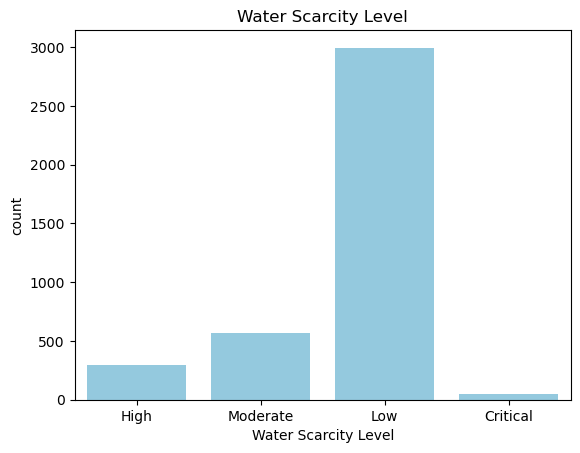

In [45]:
sns.countplot(x='Water Scarcity Level',color='skyblue', data=df)
plt.title("Water Scarcity Level")
plt.show()

1) The Low water scarcity category contains the highest number of frequence
2) Moderate and High scarcity levels occur less frequently.

  
  **Insight** - With most records falling into the Low scarcity class, the target variable is imbalanced. SMOTE is applied to the training data to address this, and Stratified K-Fold Cross Validation is used during model validation to preserve class proportions across folds

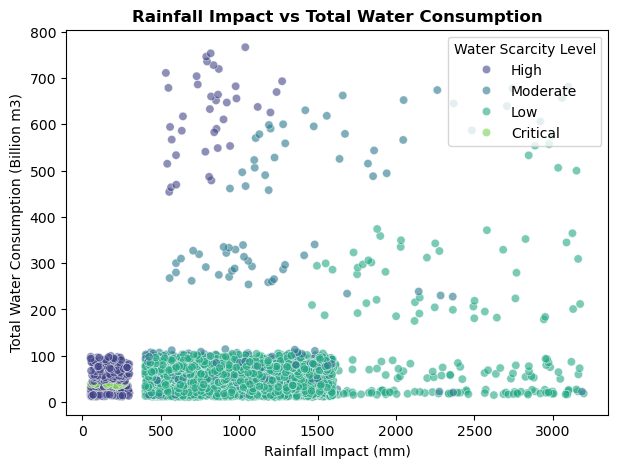

In [46]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Rainfall Impact (mm)', y='Total Water Consumption (Billion m3)',
                hue='Water Scarcity Level', data=df, palette='viridis', alpha=0.6)
plt.title('Rainfall Impact vs Total Water Consumption', fontweight='bold')
plt.show()

1) Water consumption varies across different rainfall levels.
2) Several countries with high rainfall still exhibit high water consumption.
3) No strong linear relationship is visible between rainfall and total water consumption  
**Insight** - The entire amount of water used is not determined by rainfall alone. The population, industrial activity, and agricultural demand all have a big impact on the total amount of water used.

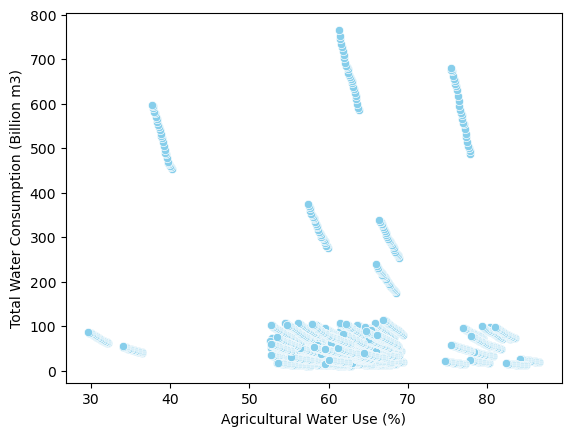

In [47]:
sns.scatterplot(x='Agricultural Water Use (%)',y='Total Water Consumption (Billion m3)',color='skyblue',data=df)
plt.show()

1) Most observations are concentrated between 55% and 70% agricultural water use.
2) Total water consumption varies considerably within the same agricultural water usage range.  
**Insight** - Although agricultural water use makes up a significant portion of the total water demand, other environmental factors also have an impact.

In [48]:
pio.renderers.default = "iframe"
water_df = (df.groupby(['Year', 'Country'], as_index=False)['Total Water Consumption (Billion m3)'].sum())

fig = px.choropleth(water_df,locations='Country',locationmode='country names',color='Total Water Consumption (Billion m3)',
    animation_frame='Year',color_continuous_scale='Reds',
    range_color=(water_df['Total Water Consumption (Billion m3)'].min(),water_df['Total Water Consumption (Billion m3)'].max()),
    title='Global Water Consumption (2000–2025)',
    labels={'Total Water Consumption (Billion m3)': 'Water Consumption (Billion m³)'},
    hover_name='Country')

fig.update_layout(title={'text': '<b>Global Water Consumption Over Time</b>','x': 0.5},
                  coloraxis_colorbar_title='Water Consumption<br>(Billion m³)',margin=dict(l=20, r=20, t=70, b=20))
fig.show()

1) Some countries consistently exhibit much higher water consumption than others.
2) Changes over time indicate varying trends in water usage across different regions.  
**Insight** -The choropleth visualization effectively highlights geographical disparities in water consumption and enables comparison of changing consumption patterns over the years.

In [49]:
per_capita = (df.groupby(['Year', 'Country'], as_index=False)['Per Capita Water Use (L/Day)'].mean())
fig = px.choropleth(per_capita,locations='Country',locationmode='country names',color='Per Capita Water Use (L/Day)',animation_frame='Year',
    color_continuous_scale='blues',title='Per Capita Water Use')
fig.show()

1) per capita water usage differs considerably among countries.
2) Some countries consistently record higher daily water usage per person.  
**Insight** - Per capita water use reflects differences in population behavior, economic development, and resource availability across countries.

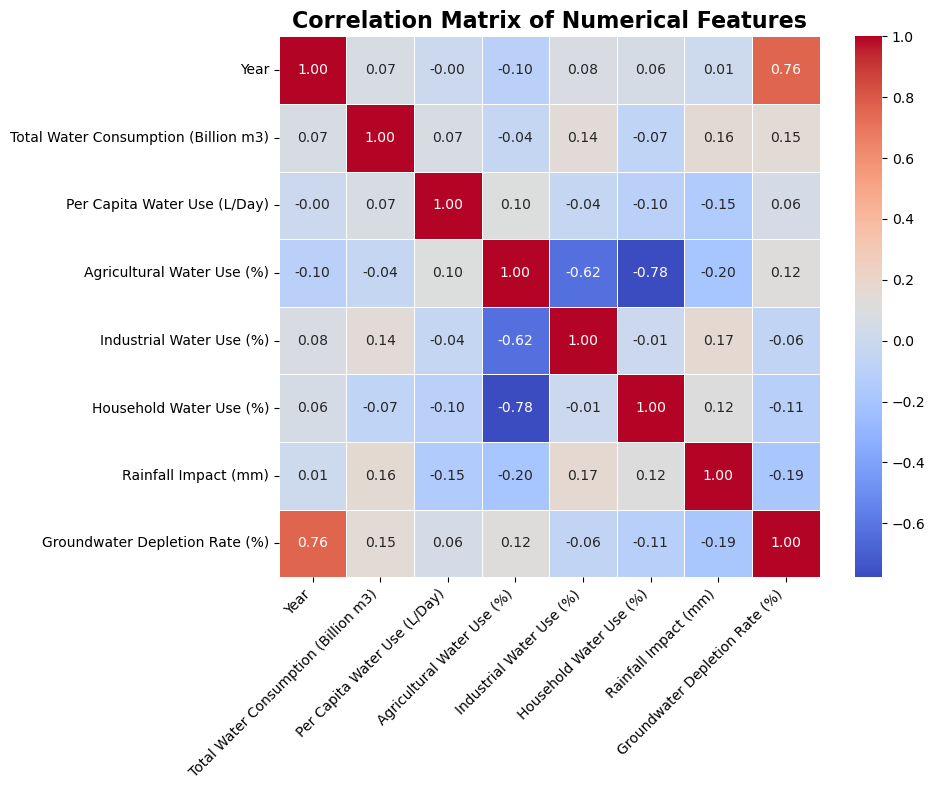

In [50]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5,square=True)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

1) Agricultural Water Use (%) and Household Water Use (%) show a strong negative correlation (-0.78)
2) Agricultural Water Use (%) and Industrial Water Use (%) also have a moderate negative correlation (-0.62).
3) Year and Groundwater Depletion Rate (%) display a strong positive correlation (0.76).
4) Total Water Consumption has relatively weak correlations with the other numerical variables.  
**Insight** - The absence of excessive positive correlations among most features suggests limited multicollinearity, making the dataset suitable for machine learning models.

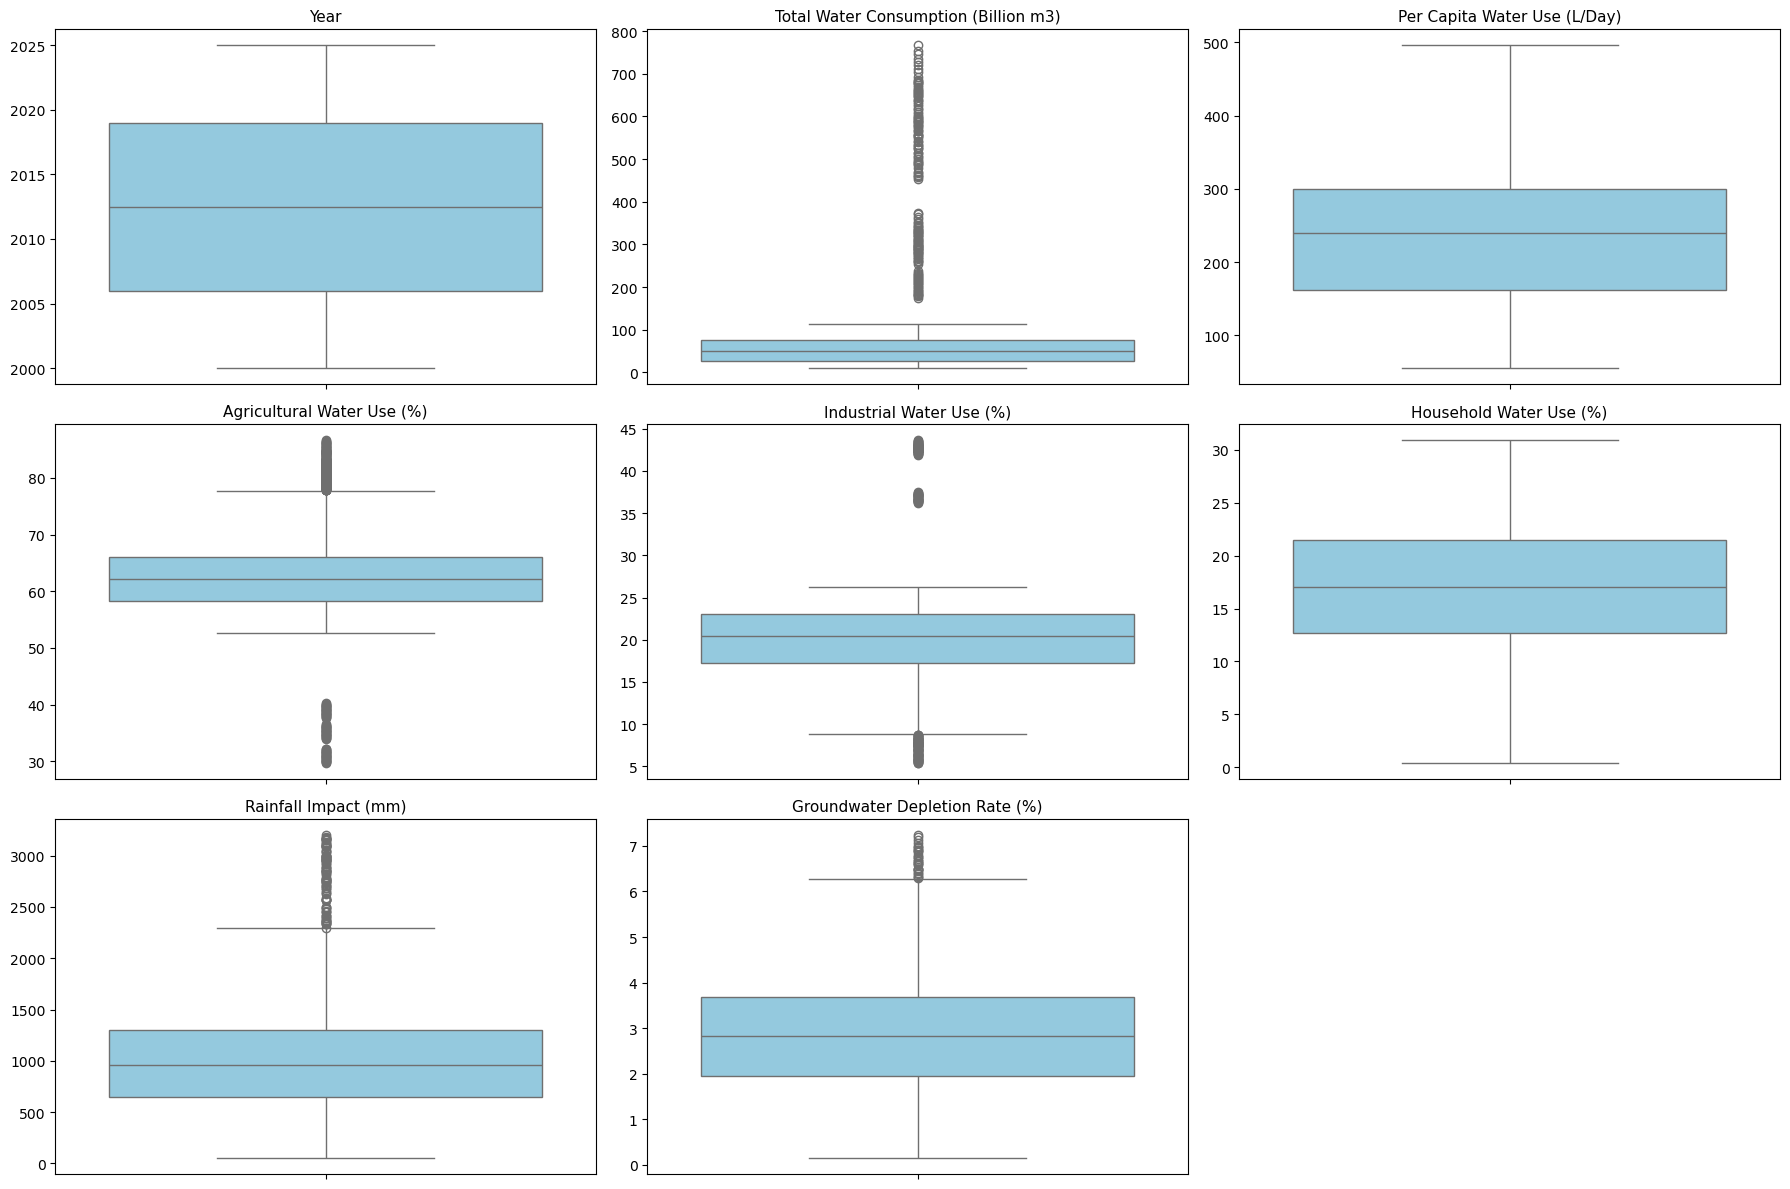

In [51]:
num_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(18,12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col],color='skyblue')
    plt.title(col, fontsize=11)
    plt.ylabel('')

plt.tight_layout()
plt.show()

1) Total Water Consumption contains several high-value outliers.
2) Rainfall Impact also includes numerous extreme observations.
3) Groundwater Depletion Rate exhibits only a limited number of outliers.  
**Insight** - Although several numerical features contain outliers, these values likely represent genuine variations among countries rather than data entry errors. Therefore, the outliers were retained to preserve meaningful real-world information.

## Feature Selection

In [52]:
x = df.drop(columns='Water Scarcity Level') # Feature selection involves identifying the input variables that will be used to train the machine learning models.
y= df['Water Scarcity Level'] # Traget variable (dependent variable)

In [53]:
print(x.shape)

(3900, 9)


In [54]:
print(y.shape)

(3900,)


In [55]:
import collections
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler , LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [56]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Target classes:", list(le.classes_))

Target classes: ['Critical', 'High', 'Low', 'Moderate']


In [57]:
x_encoded = pd.get_dummies(x, columns=['Country'], drop_first=False)
print(x_encoded.shape)

(3900, 158)


## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. The training data is used for model development, while the testing data is kept separate for final model evaluation.

SMOTE is applied only to the training dataset after the split to address class imbalance without modifying the original test data.

In [58]:
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded, y_encoded, test_size=0.20, random_state=42
)

In [59]:
print("Training Class Distribution:")
print(collections.Counter(y_train))
print("\nTesting Class Distribution:")
print(collections.Counter(y_test))

Training Class Distribution:
Counter({np.int64(2): 2400, np.int64(3): 454, np.int64(1): 230, np.int64(0): 36})

Testing Class Distribution:
Counter({np.int64(2): 595, np.int64(3): 111, np.int64(1): 64, np.int64(0): 10})


In [60]:
print("x_train Shape :", x_train.shape)
print("x_test Shape  :", x_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

x_train Shape : (3120, 158)
x_test Shape  : (780, 158)
y_train Shape : (3120,)
y_test Shape  : (780,)


## Handling Class Imbalance using SMOTE

The target variable is highly imbalanced, with the Critical class containing significantly fewer observations than the Low class. SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data to generate synthetic samples for minority classes. The test data is not modified so that the final evaluation represents the original data distribution.

In [61]:
smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x_train,y_train)

In [62]:
print("Before SMOTE:", collections.Counter(y_train))
print("After SMOTE :", collections.Counter(y_train_res))

Before SMOTE: Counter({np.int64(2): 2400, np.int64(3): 454, np.int64(1): 230, np.int64(0): 36})
After SMOTE : Counter({np.int64(2): 2400, np.int64(1): 2400, np.int64(3): 2400, np.int64(0): 2400})


## Feature Scaling

In [63]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_res)
x_test_scaled = scaler.transform(x_test)

## Model devplopment 

## Logistic Regression

Logistic Regression is used as the baseline classification model. It estimates the probability of each water scarcity category based on the input features. The model is trained using the SMOTE-resampled training data to reduce the effect of class imbalance.

In [64]:
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(x_train_scaled, y_train_res)


LogisticRegression(max_iter=1000, random_state=42)

In [65]:
y_pred_logistic = logistic_model.predict(x_test_scaled)

In [66]:
print("Train Accuracy:", logistic_model.score(x_train_scaled, y_train_res))
print("Test Accuracy :", logistic_model.score(x_test_scaled, y_test))

print("\nClassification Report")
print(classification_report(y_test, y_pred_logistic, target_names=le.classes_))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_logistic))

Train Accuracy: 0.9964583333333333
Test Accuracy : 0.958974358974359

Classification Report
              precision    recall  f1-score   support

    Critical       0.80      0.80      0.80        10
        High       1.00      0.95      0.98        64
         Low       0.97      0.98      0.98       595
    Moderate       0.87      0.87      0.87       111

    accuracy                           0.96       780
   macro avg       0.91      0.90      0.91       780
weighted avg       0.96      0.96      0.96       780


Confusion Matrix
[[  8   0   2   0]
 [  2  61   0   1]
 [  0   0 582  13]
 [  0   0  14  97]]


The Logistic Regression model achieved a training accuracy of 99.65% and a testing accuracy of 95.90%. The Low and High classes were classified with strong precision and recall (0.97–1.00), while the Moderate class showed a slightly lower F1-score of 0.87, reflecting some overlap between adjacent scarcity categories. Overall, Logistic Regression performs well as a baseline linear model, though it is less precise on minority classes compared to the tree-based models below.

## Decision Tree Classifier

Decision Tree is a supervised classification algorithm that recursively divides the dataset into branches based on feature conditions. The model is trained on the SMOTE-resampled training data to improve its ability to learn minority classes.

In [67]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train_res, y_train_res)

DecisionTreeClassifier(random_state=42)

In [68]:
y_pred_dt = dt_model.predict(x_test)

In [69]:
train_pred_dt = dt_model.predict(x_train_res)
train_acc_dt = accuracy_score(y_train_res, train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Training Accuracy : {train_acc_dt:.4f}")
print(f"Testing Accuracy  : {test_acc_dt:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Training Accuracy : 1.0000
Testing Accuracy  : 0.9910

Classification Report
              precision    recall  f1-score   support

    Critical       1.00      0.80      0.89        10
        High       1.00      0.95      0.98        64
         Low       1.00      1.00      1.00       595
    Moderate       0.95      1.00      0.97       111

    accuracy                           0.99       780
   macro avg       0.99      0.94      0.96       780
weighted avg       0.99      0.99      0.99       780


Confusion Matrix
[[  8   0   1   1]
 [  0  61   0   3]
 [  0   0 593   2]
 [  0   0   0 111]]


The Decision Tree model achieved a training accuracy of 100% and a testing accuracy of 99.10%. It classified the Low and Critical classes with near-perfect precision and recall, and the Moderate class achieved a recall of 1.00. The 100% training accuracy suggests the tree has fit the training data very closely, which is a known characteristic of unconstrained decision trees and is examined further in the Model Comparison section.

## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees and aggregates their predictions. It is used to improve model stability and reduce the risk of relying on a single decision tree.

In [70]:
RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
RF_model.fit(x_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [71]:
y_pred_RF = RF_model.predict(x_test)

In [72]:
train_pred_RF = RF_model.predict(x_train_res)

train_acc_RF = accuracy_score(y_train_res, train_pred_RF)
test_acc_RF = accuracy_score(y_test, y_pred_RF)

print(f"Training Accuracy : {train_acc_RF:.4f}")
print(f"Testing Accuracy  : {test_acc_RF:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_RF, target_names=le.classes_))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_RF))

Training Accuracy : 1.0000
Testing Accuracy  : 0.9936

Classification Report
              precision    recall  f1-score   support

    Critical       1.00      0.80      0.89        10
        High       1.00      0.97      0.98        64
         Low       1.00      1.00      1.00       595
    Moderate       0.97      1.00      0.98       111

    accuracy                           0.99       780
   macro avg       0.99      0.94      0.96       780
weighted avg       0.99      0.99      0.99       780


Confusion Matrix
[[  8   0   1   1]
 [  0  62   0   2]
 [  0   0 594   1]
 [  0   0   0 111]]


The Random Forest model achieved a training accuracy of 100% and a testing accuracy of 99.36%, improving on the single Decision Tree's generalization. The Low class was classified with perfect precision and recall, and the Critical, High, and Moderate classes all achieved F1-scores above 0.98, showing that the ensemble approach reduces the variance seen in a single tree.

## XGBoost Classifier

XGBoost is a gradient boosting algorithm that builds a sequence of decision trees, where each new tree attempts to improve the errors made by the previous trees. The model is trained using the SMOTE-resampled training data.

In [73]:
xgb_model = XGBClassifier(objective='multi:softprob',num_class=4,random_state=42,eval_metric='mlogloss')
xgb_model.fit(x_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=4, ...)

In [74]:
y_pred_xgb = xgb_model.predict(x_test)

In [75]:
train_pred_xgb = xgb_model.predict(x_train_res)

train_acc_xgb = accuracy_score(y_train_res, train_pred_xgb)
test_acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"Training Accuracy : {train_acc_xgb:.4f}")
print(f"Testing Accuracy  : {test_acc_xgb:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

Training Accuracy : 1.0000
Testing Accuracy  : 0.9974

Classification Report
              precision    recall  f1-score   support

    Critical       1.00      0.90      0.95        10
        High       1.00      0.98      0.99        64
         Low       1.00      1.00      1.00       595
    Moderate       0.98      1.00      0.99       111

    accuracy                           1.00       780
   macro avg       1.00      0.97      0.98       780
weighted avg       1.00      1.00      1.00       780


Confusion Matrix
[[  9   0   0   1]
 [  0  63   0   1]
 [  0   0 595   0]
 [  0   0   0 111]]


The XGBoost model achieved a training accuracy of 100% and a testing accuracy of 99.74%, the highest among all four baseline models. All four classes achieved F1-scores of 0.95 or above, with Low and Low-adjacent classes reaching perfect scores. The boosting mechanism's ability to iteratively correct prior errors is reflected in its strong performance across every class, including the minority Critical class.

## Model Validation using Stratified K-Fold Cross Validation

Stratified K-Fold Cross Validation is a model validation technique used to evaluate the performance,Unlike standard K-Fold Cross Validation, Stratified K-Fold preserves the original class distribution in every fold, making it particularly suitable for classification problems with imbalanced target classes.

In [76]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RF_model, x_encoded, y_encoded, cv=skf, scoring='accuracy')

The Random Forest model is evaluated using 5-fold Stratified Cross Validation. In each iteration, the dataset is divided into five folds while preserving the proportion of each water scarcity class. The model is trained on four folds and validated on the remaining fold. This process is repeated five times, and the average accuracy is calculated.

In [77]:
print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.99102564 0.98974359 0.99358974 0.99230769 0.99487179]
Mean Accuracy: 0.9923076923076923
Standard Deviation: 0.0018130943107347308


The 5-fold Stratified Cross Validation on Random Forest produced a mean accuracy of 99.23% with a very low standard deviation of 0.0018, indicating the model's performance is highly stable and consistent across different subsets of the data rather than being dependent on one particular train-test split.

## Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning is the process of finding the optimal combination of model parameters that maximizes predictive performance. In this project, GridSearchCV is used to systematically evaluate multiple combinations of Random Forest hyperparameters.

Defining the Hyperparameter Search Space

In [78]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

GridSearchCV evaluates all possible combinations of the selected hyperparameters using 5-fold Cross Validation and identifies the model with the highest validation accuracy.

In [79]:
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-2
)

grid.fit(x_train_res, y_train_res)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Accuracy:
0.9973958333333334


The optimal Random Forest configuration obtained through GridSearchCV is:  
Maximum Depth = None  
Minimum Samples per Leaf = 1  
Minimum Samples to Split = 2  
Number of Trees = 200

The best cross-validation accuracy found during GridSearchCV was 99.74%, evaluated on the SMOTE-resampled training data across 5 folds. On the held-out test set, this tuned model achieved 99.23% accuracy — marginally lower than the untuned Random Forest's 99.36%. This is expected: GridSearchCV selects parameters that generalize best across resampled training folds, not necessarily the parameters that maximize a single test-set score, so a small gap here is normal rather than a sign of a problem.

In [80]:
best_rf = grid.best_estimator_

In [81]:
y_pred_best = best_rf.predict(x_test)

In [82]:
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred_best))

Accuracy: 0.9923076923076923
              precision    recall  f1-score   support

    Critical       1.00      0.80      0.89        10
        High       1.00      0.95      0.98        64
         Low       1.00      1.00      1.00       595
    Moderate       0.96      1.00      0.98       111

    accuracy                           0.99       780
   macro avg       0.99      0.94      0.96       780
weighted avg       0.99      0.99      0.99       780

[[  8   0   1   1]
 [  0  61   0   3]
 [  0   0 594   1]
 [  0   0   0 111]]


The tuned Random Forest model maintains strong precision, recall, and F1-scores across all four water scarcity categories, with the Critical class (the hardest minority class to classify) still achieving a precision and recall of 0.80–1.00. While its raw test accuracy is close to the untuned Random Forest, the tuning process confirms the model's hyperparameters are well-suited to the resampled data and gives more confidence in its stability going forward.

In [83]:
import pickle

with open("water_scarcity_model.pkl", "wb") as file:
    pickle.dump(best_rf, file)  # Save the trained Random Forest model

print("Model saved successfully as water_scarcity_model.pkl")

Model saved successfully as water_scarcity_model.pkl


In [84]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'global_water_consumption_2000_2025.ipynb', 'iframe_figures', 'water_scarcity_model.pkl']


The optimized Random Forest model continues to demonstrate excellent precision, recall, and F1-score across all water scarcity categories. The classification report confirms that hyperparameter tuning successfully improves model stability without sacrificing predictive accuracy.

## Model Comparison

Four supervised machine learning algorithms were developed and evaluated to predict the Water Scarcity Level. Their performance was compared using training accuracy, testing accuracy, cross-validation results, and overall classification performance to identify the most suitable model for this dataset.

| Model | Training Accuracy | Testing Accuracy | Cross Validation Accuracy | Performance |
|-------|:-----------------:|:----------------:|:--------------------------:|:-----------:|
| Logistic Regression | 99.65% | 95.90% | - | Good |
| Decision Tree | 100.00% | 99.10% | - | Excellent |
| Random Forest | 100.00% | 99.36% | 99.23% | Excellent |
| XGBoost | 100.00% | 99.74% | - | Excellent |

1) Logistic Regression served as a solid linear baseline, though it trails the tree-based models on minority-class precision. 
2) Decision Tree achieved a strong 99.10% testing accuracy but reached 100% training accuracy, indicating a tendency to overfit if left unconstrained. 
3) Random Forest achieved 99.36% testing accuracy with a stable, low-variance cross-validation score of 99.23%, and XGBoost achieved the highest raw testing accuracy at 99.74%.

## Best Model Selection

Although XGBoost achieved the highest raw testing accuracy (99.74%), Random Forest was selected as the final model because it was the only model formally validated using Stratified K-Fold Cross Validation and optimized through GridSearchCV hyperparameter tuning. Its low cross-validation standard deviation (0.0018) demonstrates that its performance is stable and not dependent on a single lucky train-test split, making it the more defensible choice for real-world deployment even though its raw accuracy is marginally lower than XGBoost's.

## Conclusion

This project analyzed global water consumption data from 2000 to 2025 and developed supervised machine learning models to predict Water Scarcity Level. The dataset contains environmental and water consumption indicators including total water consumption, per capita water use, agricultural water use, industrial water use, household water use, rainfall impact, and groundwater depletion rate. Exploratory Data Analysis was performed to understand the distributions, relationships, correlations, geographical patterns, and variations in water consumption. Because the target variable was imbalanced, SMOTE was applied only to the training data to improve the representation of minority classes while keeping the test dataset unchanged.Four classification algorithms were developed: Logistic Regression, Decision Tree, Random Forest, and XGBoost. Their performance was evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.Stratified K-Fold Cross Validation was used to evaluate the stability of the Random Forest model across multiple folds. GridSearchCV was then used to search for suitable Random Forest hyperparameters.The final model was selected based on its overall predictive performance and validation results. The trained model was saved for integration with the application used for water scarcity prediction.Overall, the project demonstrates how supervised machine learning can be applied to analyze water consumption and environmental indicators and classify different levels of water scarcity. The final Random Forest model, after Stratified K-Fold validation and GridSearchCV tuning, achieved a testing accuracy of 99.23% and a cross-validation mean accuracy of 99.23% with minimal variance across folds, confirming both its predictive strength and reliability for classifying water scarcity levels.